In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Affine arithmetic library
import affapy as af
from affapy.aa import Affine
from affapy.ia import Interval

CASE 1: All independent uncertainties

In [2]:
def beam_deflection(x, P, E, L, b, h):

    I = (b * h**3)/12
    deflection = P * x**2 * ((3*L - x)/(6*E*I))

    return deflection

In [3]:
# Set a percentage to define each interval
percentage = 0.10

P_midpoint = 500 # [N]
P_lower, P_upper = P_midpoint*(1-percentage), P_midpoint*(1+percentage)
P_radius = (P_upper-P_lower)/2
P = Interval(P_lower, P_upper)

E_midpoint = 210e9 # [Pa]
E_lower, E_upper = E_midpoint*(1-percentage), E_midpoint*(1+percentage)
E_radius = (E_upper-E_lower)/2
E = Interval(E_lower, E_upper)

L_midpoint = 2 # [m]
L_lower, L_upper = L_midpoint*(1-percentage), L_midpoint*(1+percentage)
L_radius = (L_upper-L_lower)/2
L = Interval(L_lower, L_upper)

b_midpoint = 0.1 # [m]
b_lower, b_upper = b_midpoint*(1-percentage), b_midpoint*(1+percentage)
b_radius = (b_upper-b_lower)/2
B = Interval(b_lower, b_upper)

h_midpoint = 0.04 # [m]
h_lower, h_upper = h_midpoint*(1-percentage), h_midpoint*(1+percentage)
h_radius = (h_upper-h_lower)/2
H = Interval(h_lower, h_upper)

# Let x be deterministic for now at the free end tip
x = 2

# Compute deflection using traditional interval arithemetic
IA_deflection = beam_deflection(x, P, E, L, B, H)
print(IA_deflection)


[0.00565481919214587, 0.0255034358067432]


In [4]:
# Convert to affine arithmetic, we will use lower case symbols instead
p = Affine(interval=P)
e = Affine(interval=E)
l = Affine(interval=L)
b = Affine(interval=B)
h = Affine(interval=H)

print(p)
print(e)
print(l)
print(b)
print(h)
AA_deflection = beam_deflection(x, p, e, l, b, h) 
print(AA_deflection)
print(AA_deflection.interval)


500.0 + -50.0e1
210000000000.0 + -21000000000.0e2
2.0 + -0.2e3
0.1 + -0.01e4
0.04 + -0.004e5
0.018978460326604 + -0.0018978460326604e1 + 0.000458980106463728e2 + -0.0028467690489906e3 + 0.000458980106463728e4 + 0.00137694031939118e5 + -4.58980106463728e-5e6 + -9.63858223573829e-5e7 + -0.000151922415239494e8 + -0.000213012667409816e9 + 0.0087844203660233e10 + 0.00173798097209925e11 + 0.00161712898350849e12
[-0.000707804524649754, 0.0386647251778577]


In [5]:
# Lets assign the same uncertainty source (i.e. e1 for all variables)
p = Affine(x0=P_midpoint, xi={1:(P_radius)})
e = Affine(x0=E_midpoint, xi={2:(E_radius)})
l = Affine(x0=L_midpoint, xi={3:(L_radius)})
b = Affine(x0=b_midpoint, xi={3:(b_radius)})
h = Affine(x0=h_midpoint, xi={3:(h_radius)})

print(p)
print(e)
print(l)
print(b)
print(h)

AA_deflection_shared = beam_deflection(x, p, e, l, b, h) 
print(AA_deflection_shared)
print(AA_deflection_shared.interval)


500.0 + 50.0e1
210000000000.0 + 21000000000.0e2
2.0 + 0.2e3
0.1 + 0.01e3
0.04 + 0.004e3
0.018978460326604 + 0.0018978460326604e1 + -0.000458980106463729e2 + 0.00101084862313569e3 + -4.58980106463728e-5e13 + -9.63858223573829e-5e14 + -0.000151922415239494e15 + -0.000213012667409816e16 + 0.00878442036602331e17 + 0.00173798097209925e18 + 0.0012499448983375e19
[0.00333122041223105, 0.034625700240977]


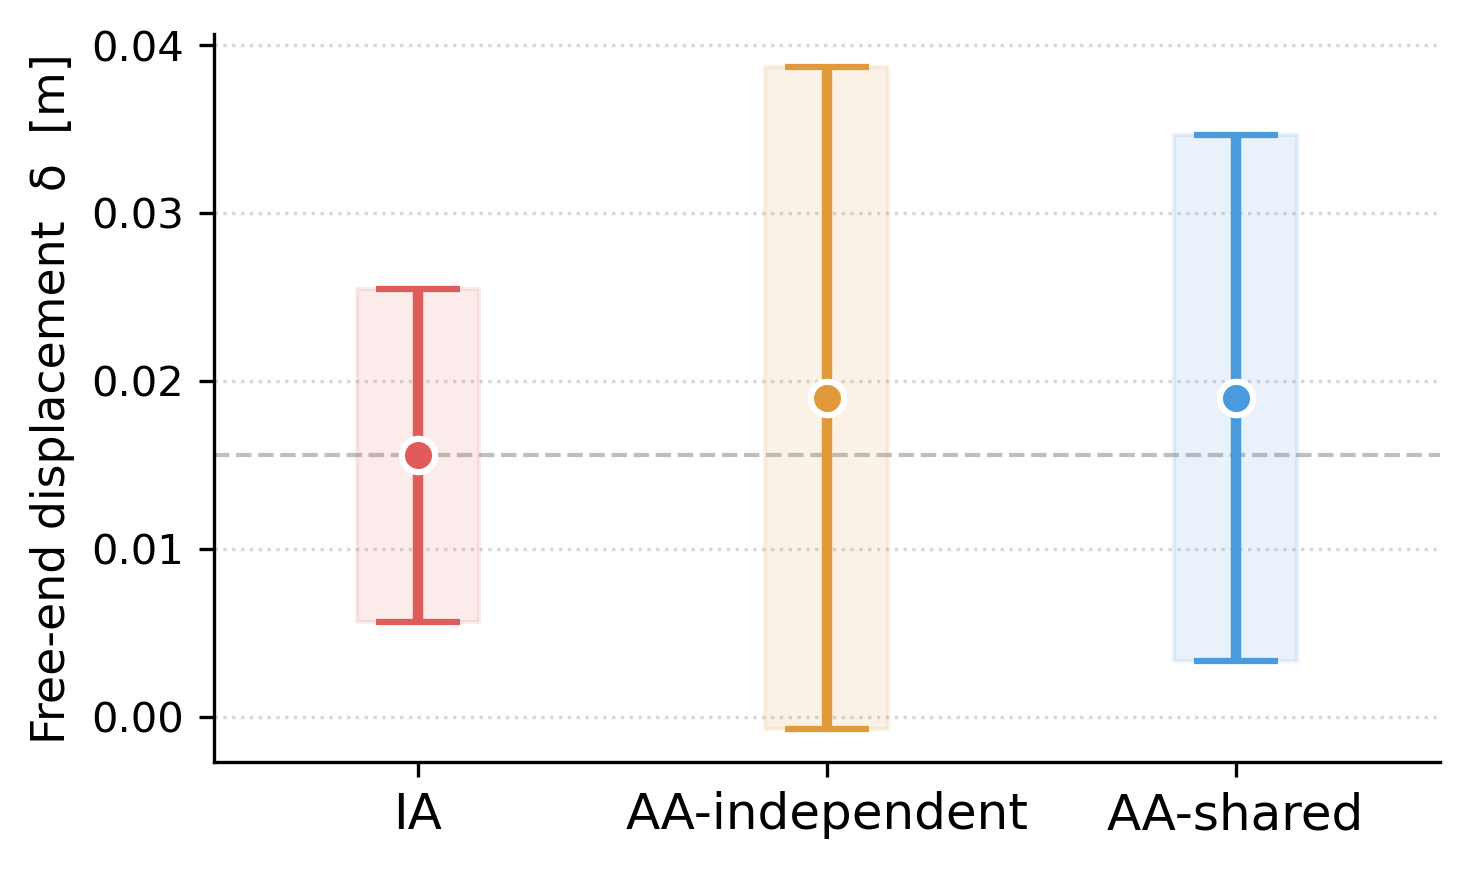

In [6]:
labels  = ["IA", "AA-independent", "AA-shared"]
centers = [float(IA_deflection.mid()),       float(AA_deflection.x0),  float(AA_deflection_shared.x0)]
errors  = [float(IA_deflection.radius()),       float(AA_deflection.rad()),  float(AA_deflection_shared.rad())]

x = np.arange(len(labels))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

colors      = ["#e05c5c", "#e09a3a", "#4a9ade"]
cap_size    = 10
marker_size = 8

for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.errorbar(
        xi, ci, yerr=ei,
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.5,
        capsize=cap_size,
        capthick=2.5,
        markersize=marker_size,
        markeredgewidth=1.5,
        markeredgecolor="white",
        label=f"{labels[i]}:  [{ci-ei:.4f}, {ci+ei:.4f}]  (width = {2*ei:.4f})",
        zorder=3,
    )

# Horizontal reference line at the nominal (central) value
ax.axhline(centers[0], color="gray", linestyle="--", linewidth=1,
           alpha=0.5, label="Nominal value")

# Shaded interval bands for visual comparison
for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.fill_between([xi - 0.15, xi + 0.15], ci - ei, ci + ei,
                    color=color, alpha=0.12, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Free-end displacement  δ  [m]", fontsize=11)

# ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()